# EDA



The final objective is to build a multimodal short-video recommender system that leverages user interactions, text metadata, and visual cover images. This EDA covers the exploration of the data relevant to this task

The EDA process is specifically designed to audit the dataset and justify our three-phase modeling progression (Popularity Baseline -> Collaborative Filtering -> Multimodal):

1. Sparsity & Distributions:
   We assess the sparsity of the User-Item matrix and analyze the "long-tail" distribution of video popularity. Understanding this power-law skew is critical for generating balanced negative samples and establishing the ceiling of our Baseline Popularity model.

2. The Cold-Start Problem:
   By identifying the volume of users and items with minimal interaction history, we expose the limitations of pure Collaborative Filtering (Model 2). This directly justifies the necessity of injecting content-based visual and text features (Model 3) to handle new, unseen videos.

3. Multimodal Feature Integrity:
   Because our final model relies heavily on content, we strictly audit the availability of the raw cover images and assess the percentage of missing text metadata (titles, descriptions). This dictates how reliably we can generate our text and image embeddings.

4. Temporal Dynamics:
   We analyze timestamp distributions to guarantee that the data can be split chronologically. This ensures strict temporal integrity between our training, validation, and test sets, preventing data leakage during model evaluation.


In [1]:
# Setup Google Drive
from google.colab import drive
import os
drive.mount('/content/drive')
DATASET_DIR = "/content/drive/MyDrive/PixelRec50K"


Mounted at /content/drive


## 2. Load Core Data & `PixelRecDataLoader`

In [2]:
%%writefile data_loader.py
import pandas as pd
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

class PixelRecDataLoader:
    def __init__(self, data_dir="/content/drive/MyDrive/PixelRec50K"):
        self.data_dir = data_dir
        self.covers_path = os.path.join(data_dir, "cover")
        self.interactions = None
        self.item_info = None

    def _find_file(self, target_filename, default_subfolder):
        direct_path = os.path.join(self.data_dir, target_filename)
        if os.path.exists(direct_path): return direct_path
        sub_path = os.path.join(self.data_dir, default_subfolder, target_filename)
        if os.path.exists(sub_path): return sub_path
        for f in os.listdir(self.data_dir) if os.path.exists(self.data_dir) else []:
            if 'interaction' in target_filename.lower() and 'interaction' in f.lower() and f.endswith('.csv'):
                return os.path.join(self.data_dir, f)
            if 'iteminfo' in target_filename.lower() and 'iteminfo' in f.lower() and f.endswith('.csv'):
                return os.path.join(self.data_dir, f)
            if f == target_filename:
                return os.path.join(self.data_dir, f)
        return None

    def load_csv_with_progress(self, file_path, sep=','):
        chunksize = 100000
        chunks = []
        with open(file_path, 'r', encoding='utf-8') as f:
            total_lines = sum(1 for _ in f) - 1
        with tqdm(total=total_lines, desc=f"Loading {os.path.basename(file_path)}") as pbar:
            for chunk in pd.read_csv(file_path, sep=sep, chunksize=chunksize):
                chunks.append(chunk)
                pbar.update(len(chunk))
        return pd.concat(chunks, axis=0)

    def load_interactions(self, filename="pixel50k_interaction.csv"):
        file_path = self._find_file(filename, "pixelrec_interaction")
        if not file_path: return pd.DataFrame()
        try:
            self.interactions = self.load_csv_with_progress(file_path)
            if 'user_id' not in self.interactions.columns:
                self.interactions = self.load_csv_with_progress(file_path, sep='\t')
        except Exception: return pd.DataFrame()
        return self.interactions

    def load_item_info(self, filename="item_info.csv"):
        file_path = self._find_file(filename, "pixelrec_iteminfo")
        if not file_path: return pd.DataFrame()
        try:
            self.item_info = self.load_csv_with_progress(file_path)
            if 'item_id' not in self.item_info.columns:
                self.item_info = self.load_csv_with_progress(file_path, sep='\t')
        except Exception: return pd.DataFrame()
        return self.item_info

    def get_user_interaction_counts(self):
        return self.interactions['user_id'].value_counts() if self.interactions is not None else pd.Series()

    def get_item_interaction_counts(self):
        return self.interactions['item_id'].value_counts() if self.interactions is not None else pd.Series()

    def filter_k_core(self, min_user_interactions=5, min_item_interactions=5):
        if self.interactions is None or self.interactions.empty: return self.interactions
        filtered_df = self.interactions.copy()
        while True:
            start_len = len(filtered_df)
            user_counts = filtered_df['user_id'].value_counts()
            valid_users = user_counts[user_counts >= min_user_interactions].index
            filtered_df = filtered_df[filtered_df['user_id'].isin(valid_users)]
            item_counts = filtered_df['item_id'].value_counts()
            valid_items = item_counts[item_counts >= min_item_interactions].index
            filtered_df = filtered_df[filtered_df['item_id'].isin(valid_items)]
            if len(filtered_df) == start_len: break
        return filtered_df

    def load_cover_image(self, item_id):
        img_path = os.path.join(self.covers_path, f"{item_id}.jpg")
        if not os.path.exists(img_path): return None
        return Image.open(img_path)

    def display_sample_covers(self, item_ids, n_cols=4):
        n_imgs = len(item_ids)
        n_rows = int(np.ceil(n_imgs / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
        axes = np.atleast_1d(axes).flatten()
        for i, item_id in enumerate(tqdm(item_ids, desc="Loading Images")):
            img = self.load_cover_image(item_id)
            if img is not None:
                axes[i].imshow(img)
                axes[i].set_title(item_id)
            else:
                axes[i].text(0.5, 0.5, 'Missing\nImage', ha='center', va='center')
            axes[i].axis('off')
        for i in range(n_imgs, len(axes)):
            axes[i].axis('off')
        plt.tight_layout()
        plt.show()


Writing data_loader.py


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from data_loader import PixelRecDataLoader

sns.set_theme(style="darkgrid")
loader = PixelRecDataLoader(data_dir=DATASET_DIR)

print("--- Data Loading Phase ---")
interactions_df = loader.load_interactions()
item_info_df = loader.load_item_info()

if interactions_df.empty:
    raise ValueError("Interactions not found! Ensure the shortcut 'PixelRec50K' exists in MyDrive.")


--- Data Loading Phase ---


Loading pixel50k_interaction.csv:   0%|          | 0/989494 [00:00<?, ?it/s]

Data Quality Audit

In [11]:
required_cols = ["user_id", "item_id"]
if "timestamp" in interactions_df.columns:
    required_cols.append("timestamp")

print("Shape:", interactions_df.shape)
print("\nMissing values:")
print(interactions_df[required_cols].isna().sum())

duplicate_interactions = interactions_df.duplicated(subset=["user_id", "item_id", "timestamp"] if "timestamp" in interactions_df.columns else ["user_id", "item_id"]).sum()
duplicate_user_item = interactions_df.duplicated(subset=["user_id", "item_id"]).sum()

print(f"\nExact duplicate rows: {duplicate_interactions:,}")
print(f"Repeated user-item pairs: {duplicate_user_item:,}")

print("\nSample rows:")
display(interactions_df.head())

if not item_info_df.empty:
    print("\n=== Item Metadata Quality ===")
    print("Shape:", item_info_df.shape)
    print("\nMissing values by column:")
    display(item_info_df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

Shape: (989494, 4)

Missing values:
user_id      0
item_id      0
timestamp    0
dtype: int64

Exact duplicate rows: 0
Repeated user-item pairs: 0

Sample rows:


,item_id,user_id,timestamp,datetime
0,i72138,u209296,1605059546,2020-11-11 01:52:26
1,i15530,u2444520,1628914341,2021-08-14 04:12:21
2,i95199,u1866870,1601008921,2020-09-25 04:42:01
3,i3413,u2498546,1505731122,2017-09-18 10:38:42
4,i224963,u3676118,1643894394,2022-02-03 13:19:54


## 3. Dataset Sparsity
>  We need to know if the user-item matrix is dense enough for standard Collaborative Filtering. If sparsity is too high, it justifies moving to a Multimodal approach.


In [4]:
num_users = interactions_df['user_id'].nunique()
num_items = interactions_df['item_id'].nunique()
num_interactions = len(interactions_df)

sparsity = 1.0 - (num_interactions / (num_users * num_items))

print(f"Total Unique Users: {num_users:,}")
print(f"Total Unique Items: {num_items:,}")
print(f"Total Interactions: {num_interactions:,}")
print(f"Dataset Sparsity:   {sparsity:.4%} (Highly sparse matrix!)")


Total Unique Users: 50,000
Total Unique Items: 82,865
Total Interactions: 989,494
Dataset Sparsity:   99.9761% (Highly sparse matrix!)


## 4. User History Length & Video Popularity Distribution
> Understanding the long-tail distribution helps us see if a few videos dominate all views, and helps us prepare for negative sampling strategies later.


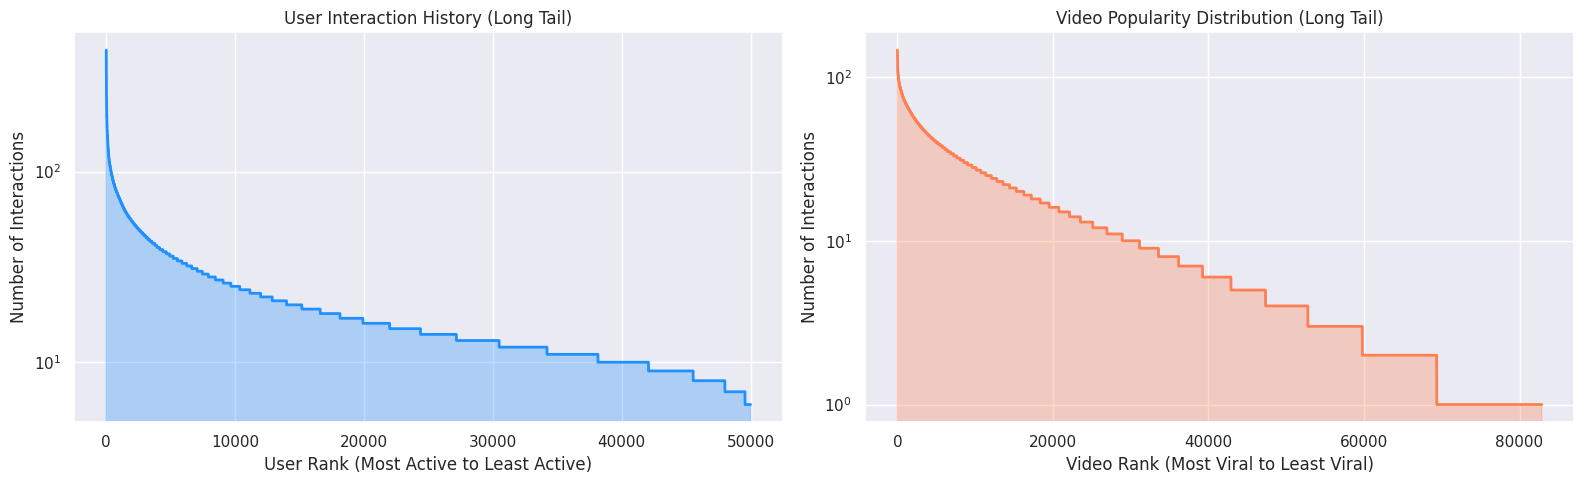

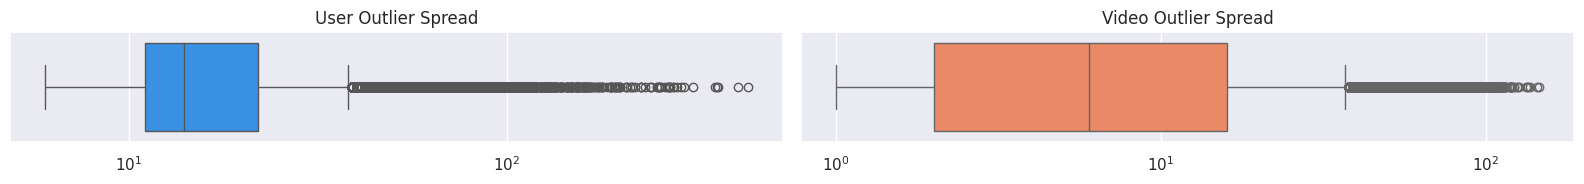

Top 1% of users account for the vast majority of interactions.
Highest active user watched: 434 videos
Most viral video watched by: 146 users


In [5]:
user_counts = loader.get_user_interaction_counts()
item_counts = loader.get_item_interaction_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(range(len(user_counts)), user_counts.values, color="dodgerblue", linewidth=2)
axes[0].fill_between(range(len(user_counts)), user_counts.values, alpha=0.3, color="dodgerblue")
axes[0].set_title('User Interaction History (Long Tail)')
axes[0].set_xlabel('User Rank (Most Active to Least Active)')
axes[0].set_ylabel('Number of Interactions')
axes[0].set_yscale('log') # We only log the Y-axis to handle the massive spread cleanly

axes[1].plot(range(len(item_counts)), item_counts.values, color="coral", linewidth=2)
axes[1].fill_between(range(len(item_counts)), item_counts.values, alpha=0.3, color="coral")
axes[1].set_title('Video Popularity Distribution (Long Tail)')
axes[1].set_xlabel('Video Rank (Most Viral to Least Viral)')
axes[1].set_ylabel('Number of Interactions')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 2))
sns.boxplot(x=user_counts, ax=axes2[0], color="dodgerblue").set(title="User Outlier Spread", xscale="log", xlabel="")
sns.boxplot(x=item_counts, ax=axes2[1], color="coral").set(title="Video Outlier Spread", xscale="log", xlabel="")
plt.tight_layout()
plt.show()

print(f"Top 1% of users account for the vast majority of interactions.")
print(f"Highest active user watched: {user_counts.max():,} videos")
print(f"Most viral video watched by: {item_counts.max():,} users")



## 5. Cold-Start Problem Analysis
> Identifying how much of our dataset is "cold" (< 5 interactions) justifies our Multimodal approach, since interaction-only models fail on new items.


In [6]:
cold_users = user_counts[user_counts < 5].count()
cold_items = item_counts[item_counts < 5].count()

print(f"Users with <5 interactions (Cold Users): {cold_users:,} ({cold_users/num_users:.1%})")
print(f"Items with <5 interactions (Cold Items): {cold_items:,} ({cold_items/num_items:.1%})")


Users with <5 interactions (Cold Users): 0 (0.0%)
Items with <5 interactions (Cold Items): 35,533 (42.9%)


## 6. Text Metadata Quality (Missing Values)
> We must audit metadata completeness. If videos are missing descriptions, text embeddings will be noisy.


In [7]:
if not item_info_df.empty:
    missing = item_info_df.isnull().sum()
    missing_pct = (missing / len(item_info_df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})

    print("Metadata Missing Values Assessment:")
    display(missing_df[missing_df['Missing Count'] >= 0].sort_values(by='Missing Count', ascending=False))


## 7. Availability & Quality of Cover Images
> We must visually inspect the images to ensure they load correctly before extracting features.

Sampling video covers directly from Google Drive shortcut...


Loading Images:   0%|          | 0/8 [00:00<?, ?it/s]

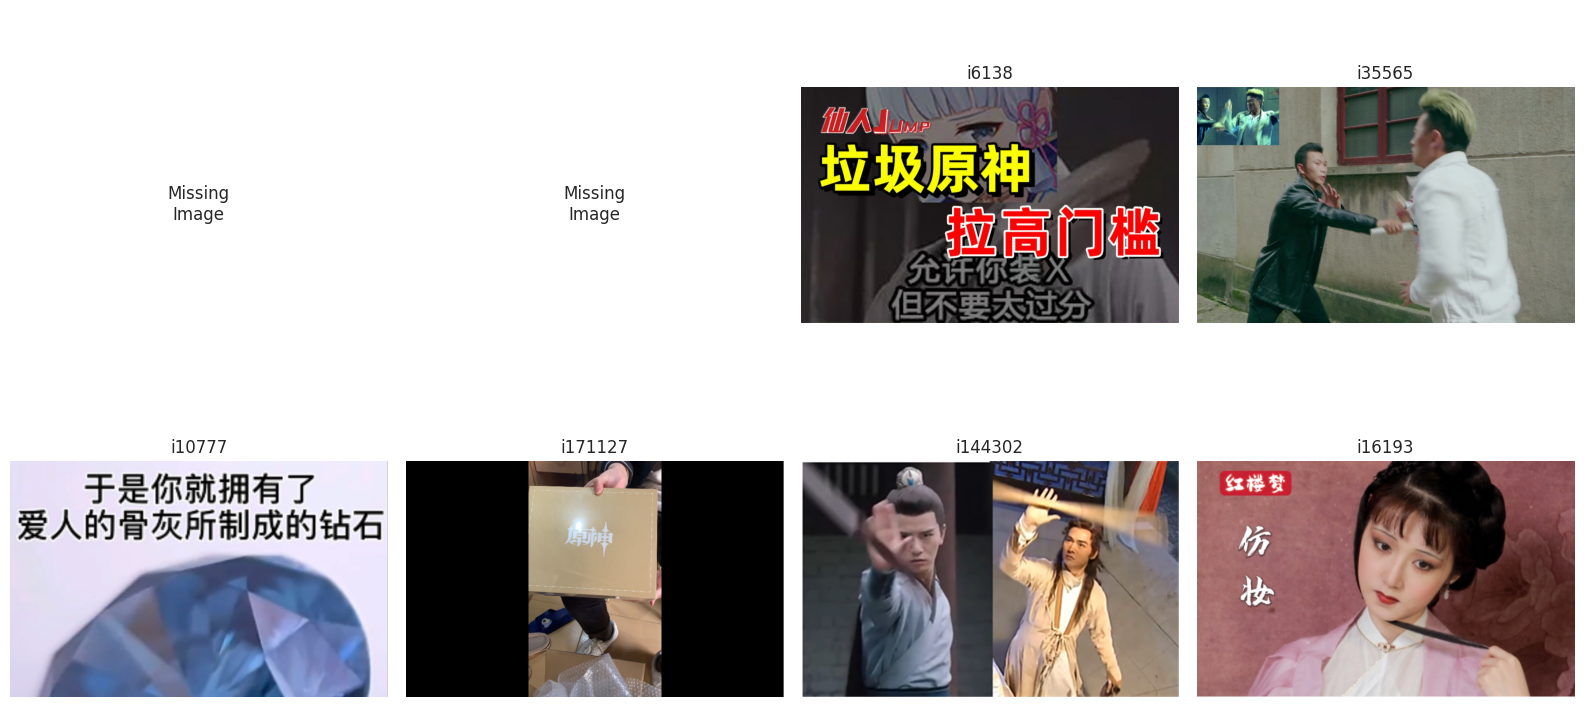

In [8]:
sample_items = item_counts.index[10:18].tolist()
print("Sampling video covers directly from Google Drive shortcut...")
loader.display_sample_covers(sample_items, n_cols=4)


## 8. Temporal Sequence Order
> Verifying timestamp presence ensures we can do chronological splits in the future modeling phase to avoid data leakage.


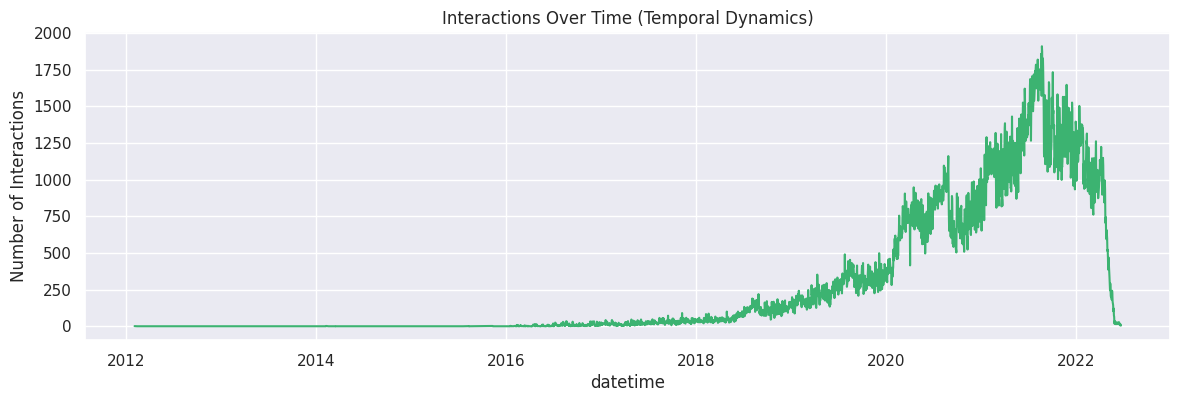

In [10]:
if 'timestamp' in interactions_df.columns:
    interactions_df['datetime'] = pd.to_datetime(interactions_df['timestamp'], unit='s', errors='coerce')
    daily = interactions_df.groupby(interactions_df['datetime'].dt.date).size()

    plt.figure(figsize=(14, 4))
    daily.plot(color="mediumseagreen")
    plt.title('Interactions Over Time (Temporal Dynamics)')
    plt.ylabel('Number of Interactions')
    plt.show()


The interaction volume changes substantially over time. Activity is very low before 2018, increases rapidly after 2019, peaks around 2021, and then drops sharply in 2022 because the dataset only extends to June 2022. For our project, this means user behavior is time-dependent, so a random train/test split may create temporal leakage by mixing future interactions into training. A chronological split is more appropriate because it tests whether the model can use past interactions to predict future recommendations.

## 9. User/Item Activity Summary

In [12]:
# User and Item Activity Summary
user_counts = interactions_df["user_id"].value_counts()
item_counts = interactions_df["item_id"].value_counts()

summary = pd.DataFrame({
    "metric": [
        "users",
        "items",
        "interactions",
        "avg interactions per user",
        "median interactions per user",
        "avg interactions per item",
        "median interactions per item",
        "max interactions by one user",
        "max interactions for one item"
    ],
    "value": [
        interactions_df["user_id"].nunique(),
        interactions_df["item_id"].nunique(),
        len(interactions_df),
        user_counts.mean(),
        user_counts.median(),
        item_counts.mean(),
        item_counts.median(),
        user_counts.max(),
        item_counts.max()
    ]
})

display(summary)

,metric,value
0,users,50000.000000
1,items,82865.000000
2,interactions,989494.000000
3,avg interactions per user,19.789880
4,median interactions per user,14.000000
5,avg interactions per item,11.941037
6,median interactions per item,6.000000
7,max interactions by one user,434.000000
8,max interactions for one item,146.000000


The dataset is large enough for recommender modeling, with 50,000 users, 82,865 items, and nearly 1 million interactions. Users have a reasonable amount of history on average, but many items have few interactions, as shown by the median of only 6 interactions per item. This suggests that collaborative filtering is feasible, but item sparsity may limit performance, motivating the use of metadata-based or hybrid recommendation models.

## 10. Long-Tail Quantification

Long-Tail Popularity Bias
Top 1% of items account for 7.27% of interactions
Top 5% of items account for 25.66% of interactions
Top 10% of items account for 40.95% of interactions


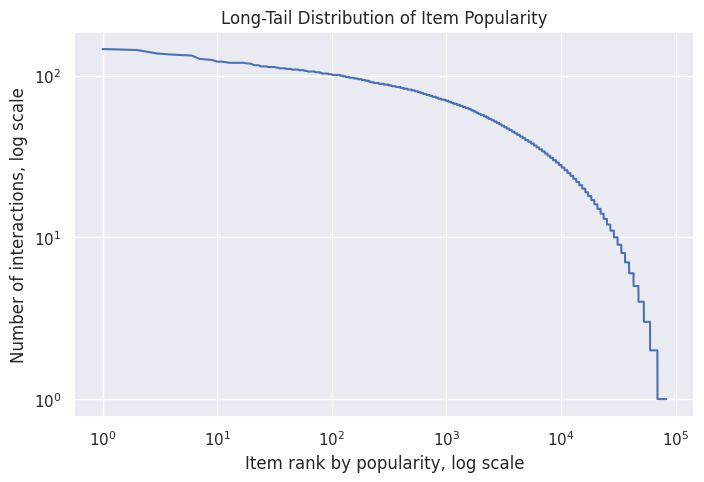

In [13]:
# Long-Tail / Popularity Bias Analysis
item_popularity = item_counts.sort_values(ascending=False)
total_interactions = item_popularity.sum()

top_1_pct_n = max(1, int(len(item_popularity) * 0.01))
top_5_pct_n = max(1, int(len(item_popularity) * 0.05))
top_10_pct_n = max(1, int(len(item_popularity) * 0.10))

top_1_share = item_popularity.iloc[:top_1_pct_n].sum() / total_interactions
top_5_share = item_popularity.iloc[:top_5_pct_n].sum() / total_interactions
top_10_share = item_popularity.iloc[:top_10_pct_n].sum() / total_interactions

print("Long-Tail Popularity Bias")
print(f"Top 1% of items account for {top_1_share:.2%} of interactions")
print(f"Top 5% of items account for {top_5_share:.2%} of interactions")
print(f"Top 10% of items account for {top_10_share:.2%} of interactions")

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(item_popularity) + 1), item_popularity.values)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Item rank by popularity, log scale")
plt.ylabel("Number of interactions, log scale")
plt.title("Long-Tail Distribution of Item Popularity")
plt.show()

The dataset has a clear long-tail popularity pattern: the top 10% of items account for about 41% of interactions. This means a popularity baseline may be strong, but it can also create popularity bias by recommending mostly popular items. Sparse long-tail items may be harder for collaborative filtering, which motivates using item metadata in a hybrid recommender.

## 11. Metadata Join Coverage

In [15]:
import os
import pandas as pd

DATASET_DIR = "/content/drive/MyDrive/PixelRec50K"

print(os.listdir(DATASET_DIR))

item_info_path = os.path.join(DATASET_DIR, "pixel50k_item_info.csv")
item_info_df = pd.read_csv(item_info_path)

print(item_info_df.shape)
print(item_info_df.columns)
display(item_info_df.head())

['cover', 'cover.7z', 'pixel50k_interaction.csv', 'pixel50k_item_info.csv']
(82865, 11)
Index(['item_id', 'view_number', 'comment_number', 'thumbup_number',
       'share_number', 'coin_number', 'favorite_number', 'barrage_number',
       'title', 'tag', 'description'],
      dtype='object')


,item_id,view_number,comment_number,thumbup_number,share_number,coin_number,favorite_number,barrage_number,title,tag,description
0,i192714,799668.0,739.0,8050.0,220.0,84.0,1049.0,510.0,"My boyfriend gave me a turtle, and it suddenly...",Pet Reptiles,Should I brush it off?
1,i225967,1201395.0,102.0,20424.0,738.0,502.0,4307.0,510.0,Who's not a baby anymore! Alaska is being bull...,Dogs,BGM: Don't Leave Me (Ne Me Quitte Pas) - Regin...
2,i8061,2633706.0,2502.0,160379.0,11161.0,2439.0,32801.0,1696.0,New York subway rules that pets can't ride the...,Dogs,wb
3,i217203,922049.0,244.0,9878.0,344.0,228.0,2129.0,1374.0,The biggest dog in the world. It's so ugly and...,Dogs,"Super love big dogs, the family has a baby Lab..."
4,i349133,186671.0,50.0,1630.0,67.0,87.0,1617.0,76.0,Taylor Swift: Selena and Mould perform Hands T...,Live Music,NaN


In [17]:
# Metadata Coverage for Hybrid Recommendation
if not item_info_df.empty and "item_id" in item_info_df.columns:
    interaction_items = set(interactions_df["item_id"].unique())
    metadata_items = set(item_info_df["item_id"].unique())

    matched_items = interaction_items.intersection(metadata_items)
    missing_metadata_items = interaction_items - metadata_items

    print("Metadata Coverage")
    print(f"Items in interactions: {len(interaction_items):,}")
    print(f"Items in item metadata: {len(metadata_items):,}")
    print(f"Interaction items with metadata: {len(matched_items):,}")
    print(f"Interaction items missing metadata: {len(missing_metadata_items):,}")
    print(f"Metadata coverage among interacted items: {len(matched_items) / len(interaction_items):.2%}")

    merged_sample = interactions_df.merge(item_info_df, on="item_id", how="left")
    print("\nMerged interaction-metadata sample:")
    display(merged_sample.head())
else:
    print("item_info_df is missing or does not contain item_id.")

Metadata Coverage
Items in interactions: 82,865
Items in item metadata: 82,865
Interaction items with metadata: 82,865
Interaction items missing metadata: 0
Metadata coverage among interacted items: 100.00%

Merged interaction-metadata sample:


,item_id,user_id,timestamp,datetime,view_number,comment_number,thumbup_number,share_number,coin_number,favorite_number,barrage_number,title,tag,description
0,i72138,u209296,1605059546,2020-11-11 01:52:26,2977267.0,12675.0,183565.0,47775.0,84001.0,83141.0,50110.0,How the trap of consumerism is slowly destroyi...,"Social Sciences, Law, and Psychology","In this video, I, as a capitalist at the botto..."
1,i15530,u2444520,1628914341,2021-08-14 04:12:21,830416.0,3103.0,50638.0,2932.0,2513.0,5878.0,3068.0,烎! 烎! 烎! China-Russia joint exercise minutes t...,Miscellaneous,Transferred from: CCTV Military #China-Russia ...
2,i95199,u1866870,1601008921,2020-09-25 04:42:01,570302.0,527.0,22810.0,187.0,1519.0,3663.0,597.0,The most important thing to remember is that i...,Food Production,"Passion Fruit Inserts g agar, g granulated sug..."
3,i3413,u2498546,1505731122,2017-09-18 10:38:42,2741154.0,5416.0,66175.0,40939.0,192009.0,112241.0,19923.0,Gee - The Ghostbusters era.,Human VOCALOID,The long-lost contribution of this video P pic...
4,i224963,u3676118,1643894394,2022-02-03 13:19:54,1132122.0,2335.0,41070.0,7882.0,10146.0,5883.0,3217.0,Fan's prediction came true! Lose Vietnam in Ha...,Basketball and Football,Losing in Hanoi is a disgrace.


The metadata coverage is 100%, meaning every item that appears in the interaction data also has corresponding metadata. This is a strong sign that the dataset is suitable for hybrid recommendation.

In addition to user-item interactions, we can incorporate item-level features such as view count, comment count, likes, shares, favorites, title, tag, and description. These features may help the model learn content-based patterns and reduce the limitations of interaction-only collaborative filtering, especially for sparse users/items or cold-start-like scenarios.

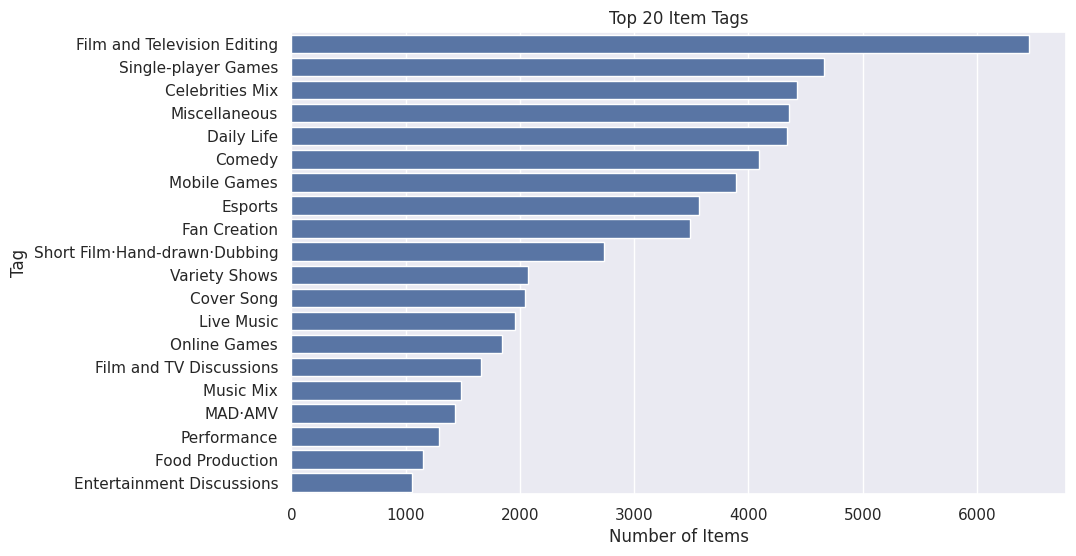

Number of unique tags: 108
Missing tag values: 5


In [18]:
# Analyze item tag distribution
tag_counts = item_info_df["tag"].fillna("Missing").value_counts().head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=tag_counts.values, y=tag_counts.index)
plt.title("Top 20 Item Tags")
plt.xlabel("Number of Items")
plt.ylabel("Tag")
plt.show()

print("Number of unique tags:", item_info_df["tag"].nunique())
print("Missing tag values:", item_info_df["tag"].isna().sum())

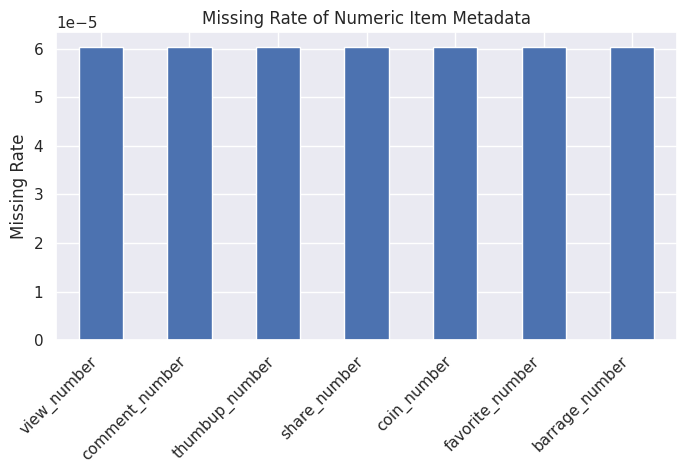

,missing_rate
view_number,0.00006
comment_number,0.00006
thumbup_number,0.00006
share_number,0.00006
coin_number,0.00006
favorite_number,0.00006
barrage_number,0.00006


In [19]:
numeric_metadata_cols = [
    "view_number", "comment_number", "thumbup_number", "share_number",
    "coin_number", "favorite_number", "barrage_number"
]

metadata_quality = item_info_df[numeric_metadata_cols].isna().mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
metadata_quality.plot(kind="bar")
plt.title("Missing Rate of Numeric Item Metadata")
plt.ylabel("Missing Rate")
plt.xticks(rotation=45, ha="right")
plt.show()

display(metadata_quality.to_frame("missing_rate"))

## 12. Temporal Split Readiness

=== Temporal Coverage ===
Earliest interaction: 2012-02-03 18:15:31
Latest interaction: 2022-06-24 16:16:00
Number of invalid timestamps: 0

Users with at least 3 unique interaction times: 50,000 / 50,000
Share of users eligible for per-user chronological train/val/test split: 100.00%


/tmp/ipykernel_20896/1260293861.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = temp_df.set_index("datetime").resample("M").size()


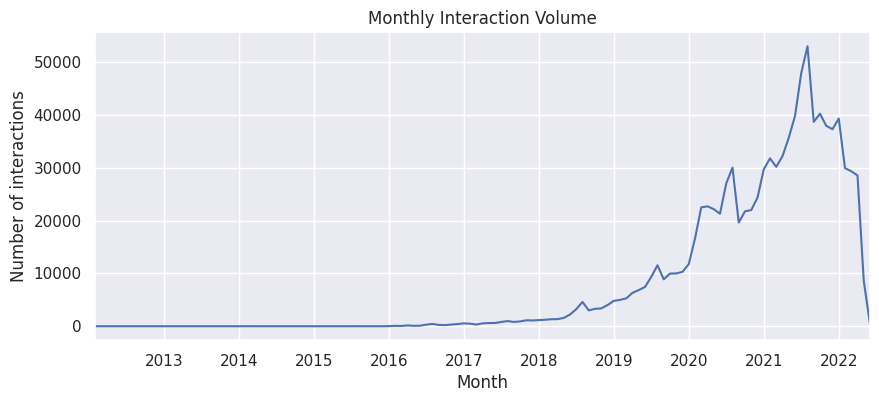


Modeling implication:
A chronological split is preferred because it evaluates whether the model can predict future interactions from past behavior.


In [21]:
# Temporal Split Readiness
if "timestamp" in interactions_df.columns:
    temp_df = interactions_df.copy()
    temp_df["datetime"] = pd.to_datetime(temp_df["timestamp"], unit="s", errors="coerce")

    print("=== Temporal Coverage ===")
    print("Earliest interaction:", temp_df["datetime"].min())
    print("Latest interaction:", temp_df["datetime"].max())
    print("Number of invalid timestamps:", temp_df["datetime"].isna().sum())

    user_time_counts = temp_df.groupby("user_id")["timestamp"].nunique()
    users_with_3plus = (user_time_counts >= 3).sum()
    total_users = temp_df["user_id"].nunique()

    print(f"\nUsers with at least 3 unique interaction times: {users_with_3plus:,} / {total_users:,}")
    print(f"Share of users eligible for per-user chronological train/val/test split: {users_with_3plus / total_users:.2%}")

    monthly_counts = temp_df.set_index("datetime").resample("M").size()

    plt.figure(figsize=(10, 4))
    monthly_counts.plot()
    plt.title("Monthly Interaction Volume")
    plt.xlabel("Month")
    plt.ylabel("Number of interactions")
    plt.show()

    print("\nModeling implication:")
    print("A chronological split is preferred because it evaluates whether the model can predict future interactions from past behavior.")
else:
    print("No timestamp column found. Use random per-user split instead.")

The interaction data spans from February 2012 to June 2022 with no invalid timestamps. Since all users have enough timestamped interactions, we can use a per-user chronological train/validation/test split, which better reflects real recommendation settings by using past behavior to predict future interactions. The drop in 2022 is likely because the dataset ends in June 2022.

In [ ]:
## 13. K-Core Filtering Impact

In [22]:
def k_core_filter(df, min_user=5, min_item=5):
    filtered = df.copy()
    while True:
        start_len = len(filtered)

        valid_users = filtered["user_id"].value_counts()
        valid_users = valid_users[valid_users >= min_user].index
        filtered = filtered[filtered["user_id"].isin(valid_users)]

        valid_items = filtered["item_id"].value_counts()
        valid_items = valid_items[valid_items >= min_item].index
        filtered = filtered[filtered["item_id"].isin(valid_items)]

        if len(filtered) == start_len:
            break

    return filtered

k_values = [2, 5, 10]
rows = []

for k in k_values:
    filtered = k_core_filter(interactions_df, min_user=k, min_item=k)
    rows.append({
        "k_core": k,
        "users_remaining": filtered["user_id"].nunique(),
        "items_remaining": filtered["item_id"].nunique(),
        "interactions_remaining": len(filtered),
        "interaction_retention": len(filtered) / len(interactions_df)
    })

kcore_summary = pd.DataFrame(rows)
display(kcore_summary)

print("Modeling implication:")
print("Higher k-core filtering reduces cold-start cases but may remove many long-tail users/items.")

,k_core,users_remaining,items_remaining,interactions_remaining,interaction_retention
0,2,50000,69347,975976,0.986338
1,5,49950,47322,913827,0.923530
2,10,30814,25614,614354,0.620877


Modeling implication:
Higher k-core filtering reduces cold-start cases but may remove many long-tail users/items.


For our project, the k-core results suggest that a 5-core filtered dataset is a reasonable modeling choice. It keeps most interactions while removing very sparse users/items that may make collaborative filtering unstable.

However, this also means our evaluation focuses more on users and items with sufficient historical interactions, so performance may not fully represent cold-start or long-tail recommendation scenarios. This motivates our comparison with hybrid models and should be discussed as a limitation.